In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage


In [ ]:

# Question 1: Load and Clean Dataset

df = pd.read_csv("marketing_campaign.csv", sep='\t')

print(df.head())

# Remove Missing Values
df = df.dropna()

# Remove Duplicates
df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

# Convert Dt_Customer column
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format="%d-%m-%Y")

print(df.info())


     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

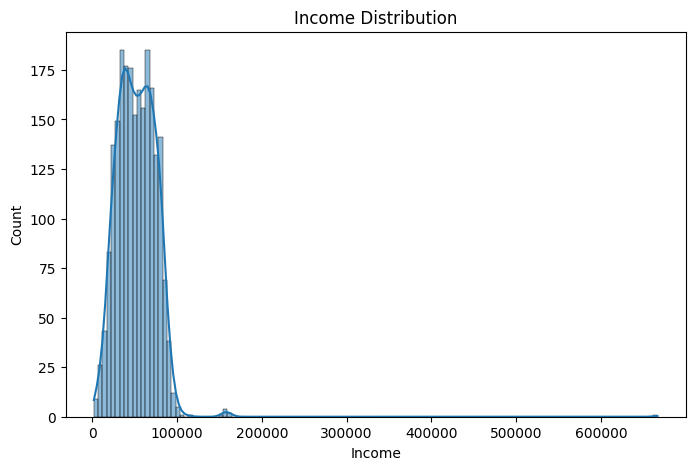

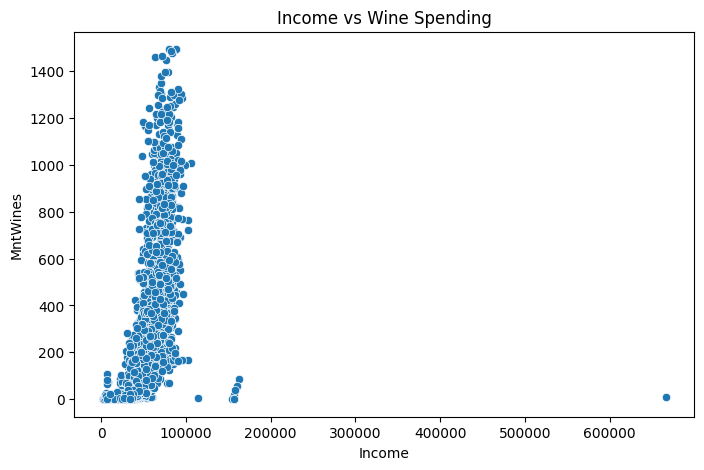

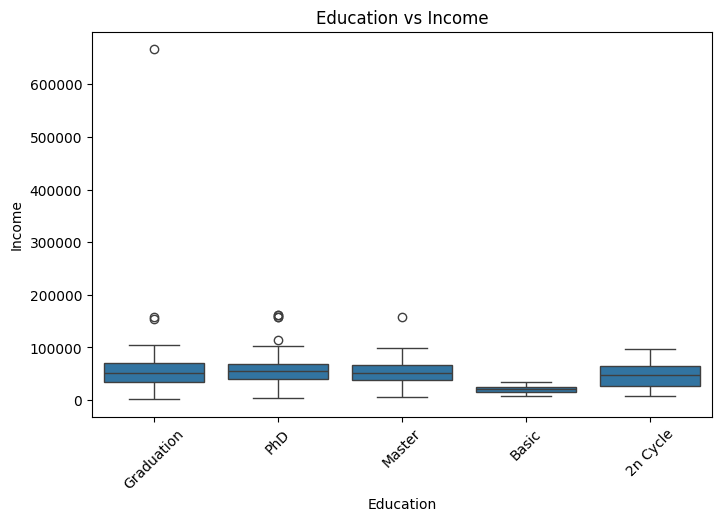

In [ ]:

# Question 2: Spending Patterns and Demographics

plt.figure(figsize=(8,5))
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Income'], y=df['MntWines'])
plt.title("Income vs Wine Spending")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Education'], y=df['Income'])
plt.xticks(rotation=45)
plt.title("Education vs Income")
plt.show()


In [ ]:

# Question 3: Normalize Numerical Features

features = ['Income', 'MntWines', 'MntMeatProducts', 'MntFishProducts']

X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])


[[ 0.2340627   0.97822575  1.69022683  2.45456767]
 [-0.23455948 -0.87202383 -0.71798612 -0.65103787]
 [ 0.76947764  0.35851074 -0.17836803  1.34020333]
 [-1.01723878 -0.87202383 -0.65555097 -0.50489173]
 [ 0.24022146 -0.39167058 -0.21850491  0.15276592]]


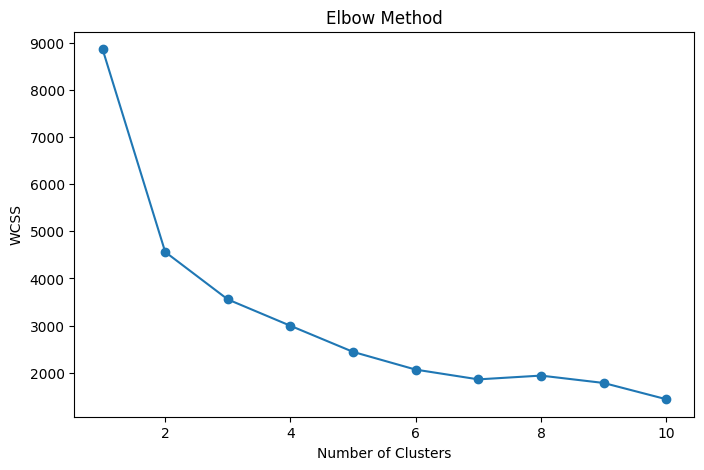

In [ ]:

# Question 4: Elbow Method

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()


In [ ]:

# Question 5: K-Means Clustering

kmeans = KMeans(n_clusters=4, random_state=42)

df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(df['KMeans_Cluster'].value_counts())

score = silhouette_score(X_scaled, df['KMeans_Cluster'])

print("Silhouette Score:", score)


KMeans_Cluster
0    1233
1     532
3     241
2     210
Name: count, dtype: int64
Silhouette Score: 0.46794743238102016


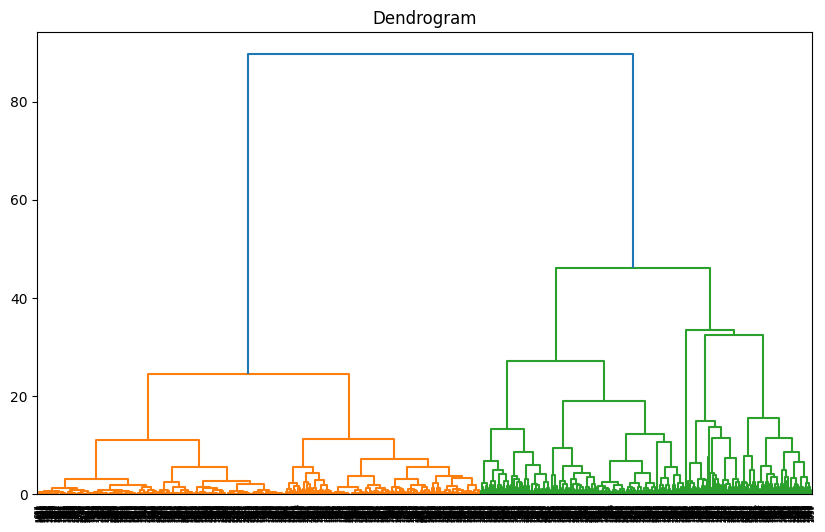

HC_Cluster
1    1268
2     585
0     362
3       1
Name: count, dtype: int64


In [ ]:

# Question 6: Hierarchical Clustering

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Dendrogram")

plt.show()

hc = AgglomerativeClustering(n_clusters=4)

df['HC_Cluster'] = hc.fit_predict(X_scaled)

print(df['HC_Cluster'].value_counts())


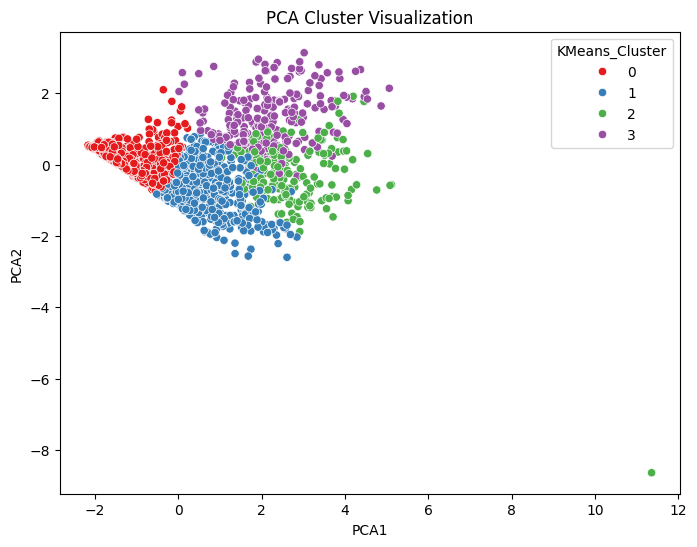

In [ ]:

# Question 7: PCA Visualization

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

df['PCA1'] = pca_result[:,0]
df['PCA2'] = pca_result[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['PCA1'],
    y=df['PCA2'],
    hue=df['KMeans_Cluster'],
    palette='Set1'
)

plt.title("PCA Cluster Visualization")

plt.show()


In [ ]:

# Question 8: Cluster Profiling

cluster_profile = df.groupby('KMeans_Cluster')[
    ['Income', 'MntWines', 'MntMeatProducts']
].mean()

print(cluster_profile)


                      Income    MntWines  MntMeatProducts
KMeans_Cluster                                           
0               36820.218167   71.326034        34.642336
1               66722.054511  611.015038       186.796992
2               83369.614286  687.980952       672.252381
3               72103.020747  492.124481       360.165975


In [ ]:

# Question 9: Dataset with Cluster IDs

print(df[['Income', 'MntWines', 'KMeans_Cluster']].head())

# Save Updated Dataset
df.to_csv("customer_segmented.csv", index=False)

print("Cluster labels added successfully.")


    Income  MntWines  KMeans_Cluster
0  58138.0       635               3
1  46344.0        11               0
2  71613.0       426               3
3  26646.0        11               0
4  58293.0       173               0
Cluster labels added successfully.


In [ ]:

# Question 10: Marketing Strategy Recommendations

strategies = {
    0: "Premium product recommendations and loyalty rewards",
    1: "Discount offers and seasonal promotions",
    2: "Cross-selling and personalized marketing",
    3: "Budget-friendly product targeting"
}

for cluster, strategy in strategies.items():
    print(f"Cluster {cluster}: {strategy}")


Cluster 0: Premium product recommendations and loyalty rewards
Cluster 1: Discount offers and seasonal promotions
Cluster 2: Cross-selling and personalized marketing
Cluster 3: Budget-friendly product targeting
